# E-commerce Sales Analysis
Exploratory data analysis of `ecommerce_sales_analytics_5000.csv`

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.2f}".format

## 1. Load the Dataset

In [2]:
df = pd.read_csv("ecommerce_sales_analytics_5000.csv")
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.70,"1,883.20"
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.90,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.50,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.60,"2,569.90"
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.90,468.56


## 2. Inspect the Data

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (5000, 12)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 468.9 KB


In [4]:
# Numeric columns
df.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,"5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00"
mean,"12,500.50","1,505.70",4.04,308.42,0.18,6.12,2.97,"1,021.96"
std,"1,443.52",290.84,2.02,169.26,0.10,3.15,1.16,825.58
min,"10,001.00","1,000.00",1.00,15.15,0.00,1.00,1.00,11.21
25%,"11,250.75","1,253.00",2.00,161.90,0.09,3.00,2.00,354.53
50%,"12,500.50","1,510.00",4.00,309.89,0.18,6.00,3.00,796.65
75%,"13,750.25","1,761.00",6.00,455.56,0.27,9.00,4.00,"1,515.69"
max,"15,000.00","1,999.00",7.00,599.96,0.35,11.00,5.00,"4,119.33"


In [5]:
# Categorical columns
df[["product_category", "region", "payment_method"]].describe()

,product_category,region,payment_method
count,5000,5000,5000
unique,4,4,3
top,Electronics,West,Card
freq,1777,1289,2270


## 3. Missing Values and Duplicates

In [6]:
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate order_id:", df["order_id"].duplicated().sum())

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

Duplicate rows: 0
Duplicate order_id: 0


In [7]:
# Nothing is removed if no missing values or duplicates were found
df = df.drop_duplicates().dropna()
print("Shape after cleaning:", df.shape)

Shape after cleaning: (5000, 12)


## 4. Convert `order_date` to Datetime

In [8]:
df["order_date"] = pd.to_datetime(df["order_date"], format="%m/%d/%Y")
df["year"] = df["order_date"].dt.year

print(df["order_date"].dtype)
print(df["order_date"].min(), "to", df["order_date"].max())

datetime64[us]
2022-01-01 00:00:00 to 2035-09-09 00:00:00


## 5. Overall Sales and Revenue

In [9]:
total_revenue = df["revenue"].sum()

print(f"Total revenue:       {total_revenue:,.2f}")
print(f"Total orders:        {len(df):,}")
print(f"Unique customers:    {df['customer_id'].nunique():,}")
print(f"Units sold:          {df['quantity'].sum():,}")
print(f"Average order value: {df['revenue'].mean():,.2f}")

Total revenue:       5,109,775.74
Total orders:        5,000
Unique customers:    989
Units sold:          20,224
Average order value: 1,021.96


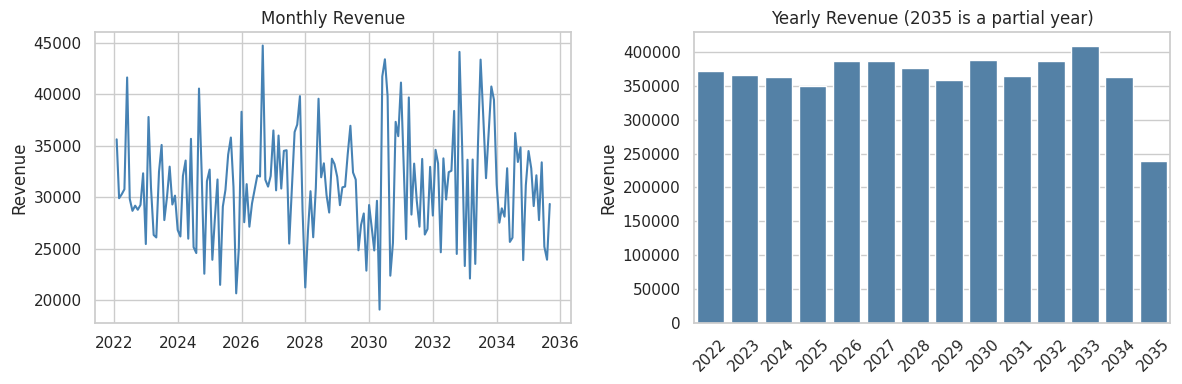

In [10]:
yearly = df.groupby("year")["revenue"].sum()
monthly = df.set_index("order_date")["revenue"].resample("ME").sum()
monthly = monthly.iloc[:-1]  # drop the last month (only 9 days of data)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(monthly.index, monthly.values, color="steelblue")
axes[0].set(title="Monthly Revenue", xlabel="", ylabel="Revenue")

sns.barplot(x=yearly.index, y=yearly.values, ax=axes[1], color="steelblue")
axes[1].set(title="Yearly Revenue (2035 is a partial year)", xlabel="", ylabel="Revenue")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Helper: Group Summary
Same summary table reused for category, region and payment method.

In [11]:
def group_summary(col):
    return df.groupby(col).agg(
        orders=("order_id", "count"),
        total_revenue=("revenue", "sum"),
        avg_order_value=("revenue", "mean"),
        avg_discount=("discount", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_rating=("customer_rating", "mean"),
    ).sort_values("total_revenue", ascending=False)

## 6. Sales by Product Category

In [12]:
category = group_summary("product_category")
category

,orders,total_revenue,avg_order_value,avg_discount,avg_delivery_days,avg_rating
product_category,,,,,,
Electronics,1777,"1,829,899.22","1,029.77",0.18,6.07,2.95
Clothing,1531,"1,531,931.72","1,000.61",0.18,6.12,3.01
Home,969,"982,083.92","1,013.50",0.18,6.15,2.94
Beauty,723,"765,860.88","1,059.28",0.18,6.20,3.01


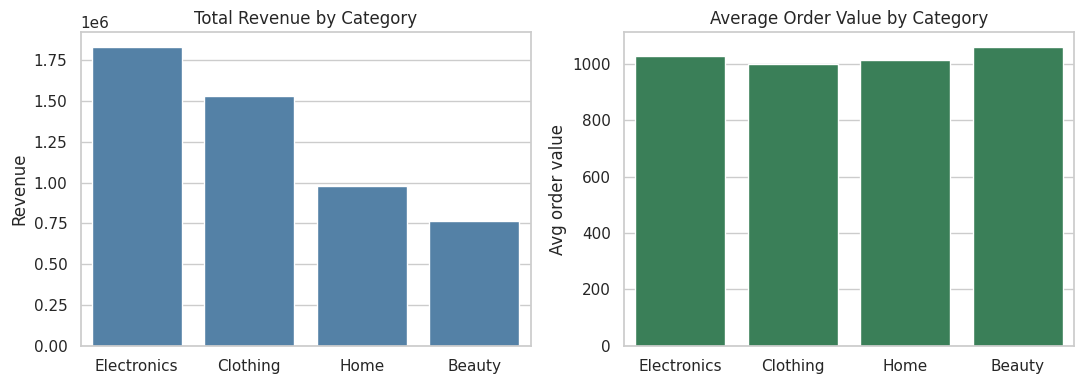

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(x=category.index, y=category["total_revenue"], ax=axes[0], color="steelblue")
axes[0].set(title="Total Revenue by Category", xlabel="", ylabel="Revenue")

sns.barplot(x=category.index, y=category["avg_order_value"], ax=axes[1], color="seagreen")
axes[1].set(title="Average Order Value by Category", xlabel="", ylabel="Avg order value")

plt.tight_layout()
plt.show()

## 7. Sales by Region

In [14]:
region = group_summary("region")
region

,orders,total_revenue,avg_order_value,avg_discount,avg_delivery_days,avg_rating
region,,,,,,
West,1289,"1,345,582.16","1,043.90",0.18,6.08,2.96
North,1276,"1,281,508.45","1,004.32",0.18,6.12,2.99
South,1208,"1,246,640.90","1,031.99",0.18,6.17,2.97
East,1227,"1,236,044.23","1,007.37",0.18,6.10,2.97


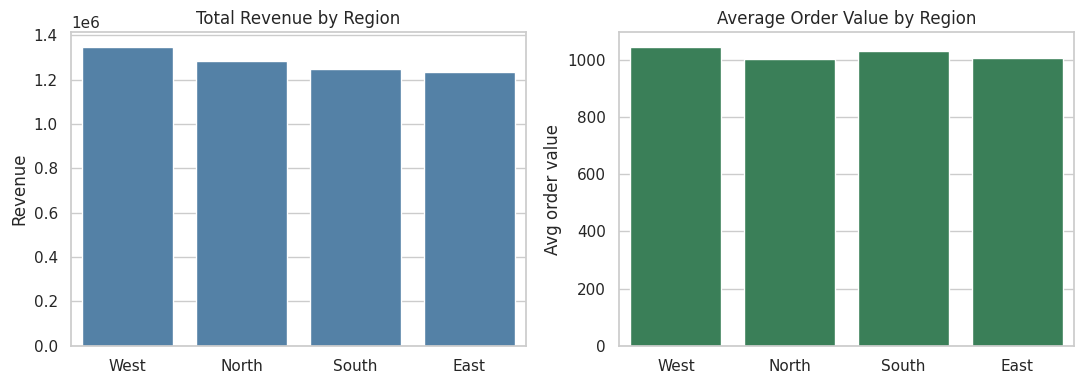

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(x=region.index, y=region["total_revenue"], ax=axes[0], color="steelblue")
axes[0].set(title="Total Revenue by Region", xlabel="", ylabel="Revenue")

sns.barplot(x=region.index, y=region["avg_order_value"], ax=axes[1], color="seagreen")
axes[1].set(title="Average Order Value by Region", xlabel="", ylabel="Avg order value")

plt.tight_layout()
plt.show()

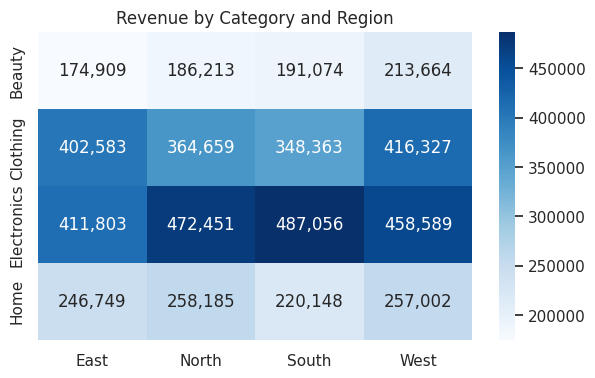

In [16]:
# Revenue by category and region
cat_region = df.pivot_table(index="product_category", columns="region", values="revenue", aggfunc="sum")

plt.figure(figsize=(7, 4))
sns.heatmap(cat_region, annot=True, fmt=",.0f", cmap="Blues")
plt.title("Revenue by Category and Region")
plt.xlabel("")
plt.ylabel("")
plt.show()

## 8. Payment Methods

In [17]:
payment = group_summary("payment_method")
payment

,orders,total_revenue,avg_order_value,avg_discount,avg_delivery_days,avg_rating
payment_method,,,,,,
Card,2270,"2,366,248.20","1,042.40",0.18,6.09,3.02
COD,1774,"1,788,408.44","1,008.12",0.18,6.16,2.94
Wallet,956,"955,119.10",999.08,0.17,6.12,2.93


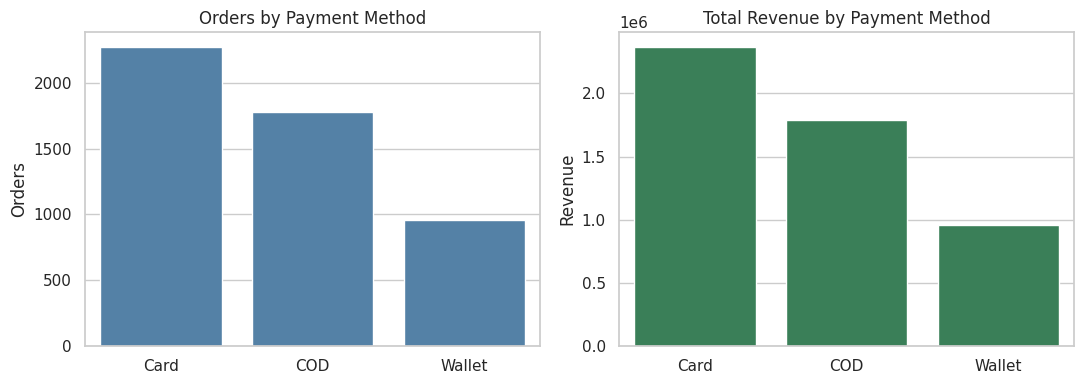

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(x=payment.index, y=payment["orders"], ax=axes[0], color="steelblue")
axes[0].set(title="Orders by Payment Method", xlabel="", ylabel="Orders")

sns.barplot(x=payment.index, y=payment["total_revenue"], ax=axes[1], color="seagreen")
axes[1].set(title="Total Revenue by Payment Method", xlabel="", ylabel="Revenue")

plt.tight_layout()
plt.show()

## 9. Discounts

In [19]:
print(df["discount"].describe())

# Total discount given (gross sales minus revenue)
df["discount_amount"] = df["quantity"] * df["unit_price"] - df["revenue"]
print(f"\nTotal discount given: {df['discount_amount'].sum():,.2f}")

count   5,000.00
mean        0.18
std         0.10
min         0.00
25%         0.09
50%         0.18
75%         0.27
max         0.35
Name: discount, dtype: float64

Total discount given: 1,130,246.22


In [20]:
# Group discounts into bands (maximum discount in the data is 35%)
df["discount_band"] = pd.cut(
    df["discount"],
    bins=[0, 0.10, 0.20, 0.30, 0.35],
    labels=["0-10%", "11-20%", "21-30%", "31-35%"],
    include_lowest=True,
)

discount = df.groupby("discount_band", observed=True).agg(
    orders=("order_id", "count"),
    total_revenue=("revenue", "sum"),
    avg_order_value=("revenue", "mean"),
    avg_quantity=("quantity", "mean"),
    avg_rating=("customer_rating", "mean"),
)
discount

,orders,total_revenue,avg_order_value,avg_quantity,avg_rating
discount_band,,,,,
0-10%,1401,"1,624,404.90","1,159.46",4.01,2.96
11-20%,1401,"1,482,197.03","1,057.96",4.07,2.96
21-30%,1502,"1,417,792.45",943.94,4.07,2.97
31-35%,696,"585,381.36",841.07,4.00,3.04


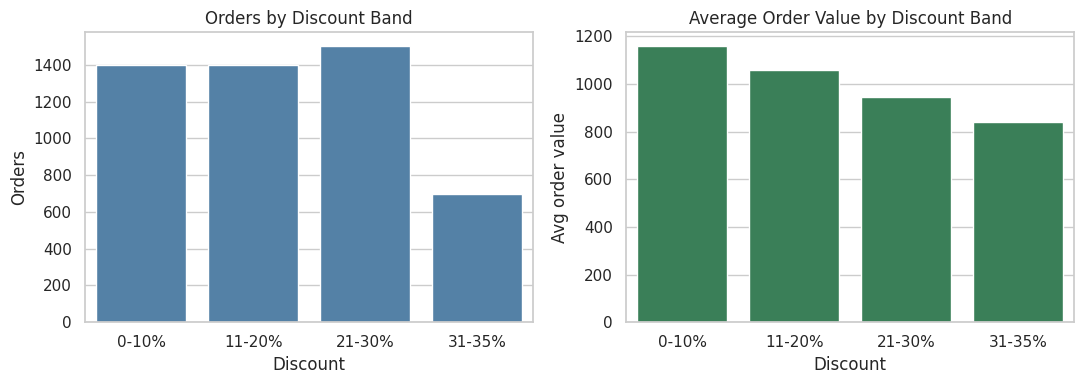

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(x=discount.index, y=discount["orders"], ax=axes[0], color="steelblue")
axes[0].set(title="Orders by Discount Band", xlabel="Discount", ylabel="Orders")

sns.barplot(x=discount.index, y=discount["avg_order_value"], ax=axes[1], color="seagreen")
axes[1].set(title="Average Order Value by Discount Band", xlabel="Discount", ylabel="Avg order value")

plt.tight_layout()
plt.show()

## 10. Delivery Days and Customer Ratings

In [22]:
df[["delivery_days", "customer_rating"]].describe()

,delivery_days,customer_rating
count,"5,000.00","5,000.00"
mean,6.12,2.97
std,3.15,1.16
min,1.00,1.00
25%,3.00,2.00
50%,6.00,3.00
75%,9.00,4.00
max,11.00,5.00


In [23]:
# Average delivery time and rating by group
pd.concat({
    "category": category[["avg_delivery_days", "avg_rating"]],
    "region": region[["avg_delivery_days", "avg_rating"]],
    "payment": payment[["avg_delivery_days", "avg_rating"]],
})

avg_delivery_days  avg_rating
category Electronics               6.07        2.95
         Clothing                  6.12        3.01
         Home                      6.15        2.94
         Beauty                    6.20        3.01
region   West                      6.08        2.96
         North                     6.12        2.99
         South                     6.17        2.97
         East                      6.10        2.97
payment  Card                      6.09        3.02
         COD                       6.16        2.94
         Wallet                    6.12        2.93

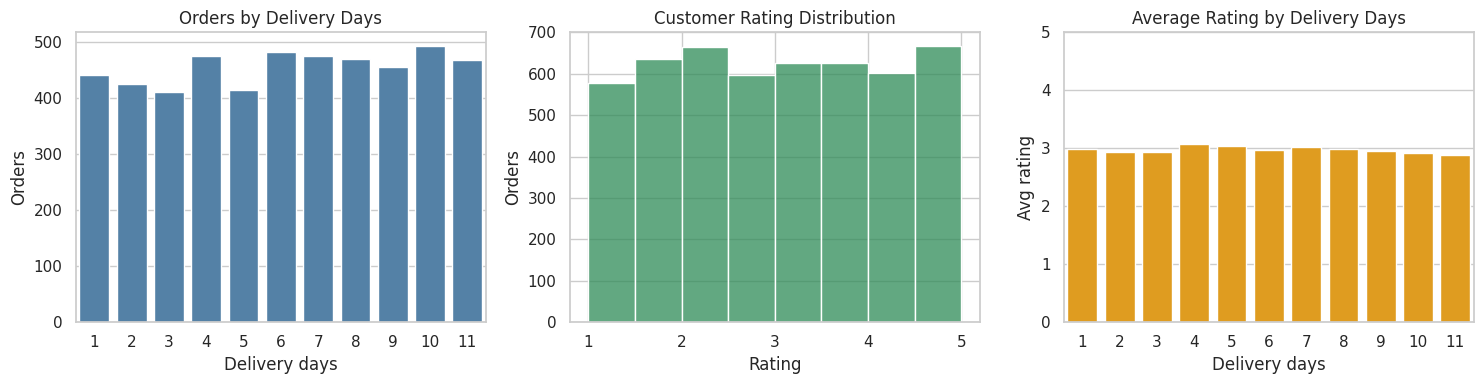

In [24]:
rating_by_delivery = df.groupby("delivery_days")["customer_rating"].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x="delivery_days", data=df, ax=axes[0], color="steelblue")
axes[0].set(title="Orders by Delivery Days", xlabel="Delivery days", ylabel="Orders")

sns.histplot(df["customer_rating"], binwidth=0.5, ax=axes[1], color="seagreen")
axes[1].set(title="Customer Rating Distribution", xlabel="Rating", ylabel="Orders")

sns.barplot(x=rating_by_delivery.index, y=rating_by_delivery.values, ax=axes[2], color="orange")
axes[2].set(title="Average Rating by Delivery Days", xlabel="Delivery days", ylabel="Avg rating", ylim=(0, 5))

plt.tight_layout()
plt.show()

## 11. Relationships Between Variables

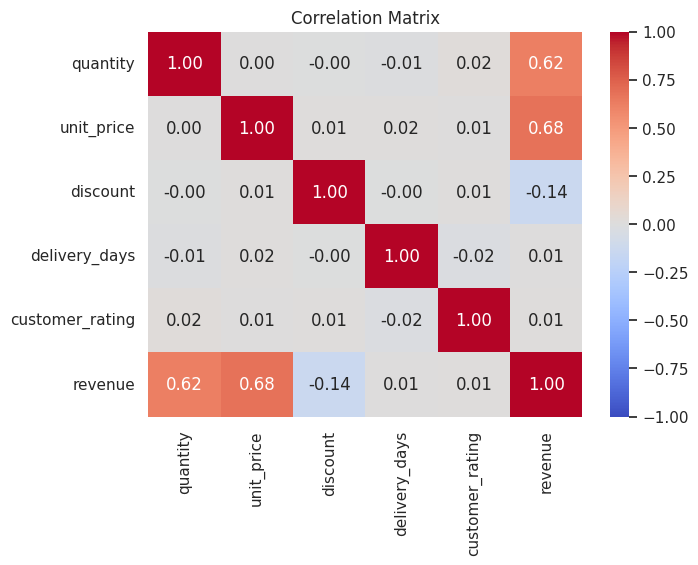

In [25]:
num_cols = ["quantity", "unit_price", "discount", "delivery_days", "customer_rating", "revenue"]
corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

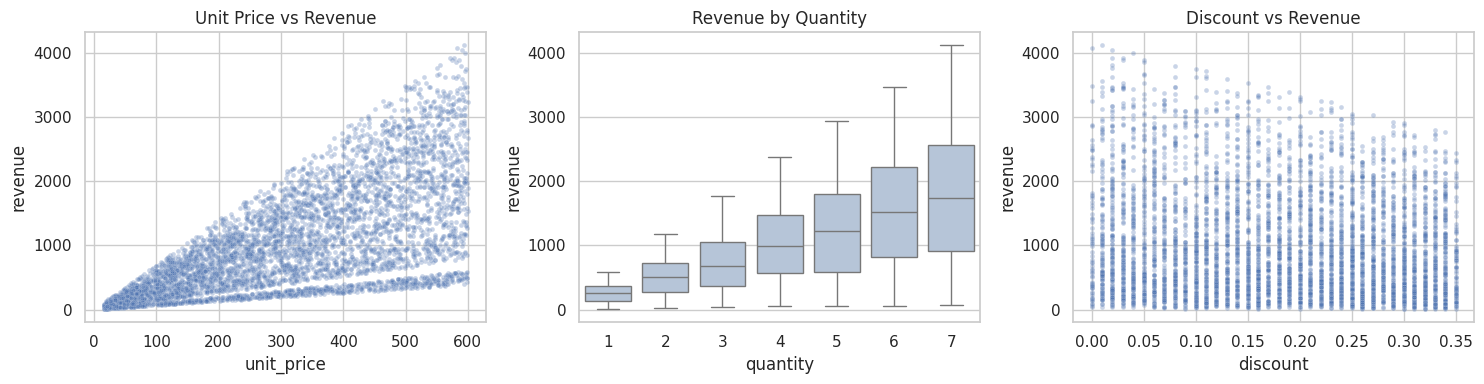

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(x="unit_price", y="revenue", data=df, ax=axes[0], alpha=0.3, s=12)
axes[0].set(title="Unit Price vs Revenue")

sns.boxplot(x="quantity", y="revenue", data=df, ax=axes[1], color="lightsteelblue")
axes[1].set(title="Revenue by Quantity")

sns.scatterplot(x="discount", y="revenue", data=df, ax=axes[2], alpha=0.3, s=12)
axes[2].set(title="Discount vs Revenue")

plt.tight_layout()
plt.show()

## 12. Key Results

In [27]:
# Overall
print(f"Total revenue:          {total_revenue:,.2f}")
print(f"Total orders:           {len(df):,}")
print(f"Average order value:    {df['revenue'].mean():,.2f}")
print(f"Average discount:       {df['discount'].mean() * 100:.1f}%")
print(f"Average delivery days:  {df['delivery_days'].mean():.2f}")
print(f"Average rating:         {df['customer_rating'].mean():.2f}")
print(f"Orders rated 4 or more: {(df['customer_rating'] >= 4).mean() * 100:.1f}%")
print(f"Orders rated 2 or less: {(df['customer_rating'] <= 2).mean() * 100:.1f}%")

Total revenue:          5,109,775.74
Total orders:           5,000
Average order value:    1,021.96
Average discount:       18.0%
Average delivery days:  6.12
Average rating:         2.97
Orders rated 4 or more: 25.4%
Orders rated 2 or less: 26.9%


In [28]:
# Top group by revenue and by average order value
for name, table in [("Category", category), ("Region", region), ("Payment method", payment)]:
    top = table["total_revenue"].idxmax()
    share = table.loc[top, "total_revenue"] / total_revenue * 100
    print(f"{name}: highest revenue = {top} ({share:.1f}% of total), "
          f"highest avg order value = {table['avg_order_value'].idxmax()}, "
          f"highest avg rating = {table['avg_rating'].idxmax()}")

Category: highest revenue = Electronics (35.8% of total), highest avg order value = Beauty, highest avg rating = Beauty
Region: highest revenue = West (26.3% of total), highest avg order value = West, highest avg rating = North
Payment method: highest revenue = Card (46.3% of total), highest avg order value = Card, highest avg rating = Card


In [29]:
# Discounts
print("Average order value by discount band:")
print(discount["avg_order_value"])
print("\nAverage rating by discount band:")
print(discount["avg_rating"])

Average order value by discount band:
discount_band
0-10%    1,159.46
11-20%   1,057.96
21-30%     943.94
31-35%     841.07
Name: avg_order_value, dtype: float64

Average rating by discount band:
discount_band
0-10%    2.96
11-20%   2.96
21-30%   2.97
31-35%   3.04
Name: avg_rating, dtype: float64


In [30]:
# Correlations
print("Correlation with revenue:")
print(corr["revenue"].drop("revenue").to_string(float_format="{:.3f}".format))
print(f"\nDelivery days vs rating: {corr.loc['delivery_days', 'customer_rating']:.3f}")
print(f"Discount vs rating:      {corr.loc['discount', 'customer_rating']:.3f}")

Correlation with revenue:
quantity           0.624
unit_price         0.678
discount          -0.139
delivery_days      0.005
customer_rating    0.012

Delivery days vs rating: -0.018
Discount vs rating:      0.013
